# Renoise decorrelation — where does the start state stop knowing the answer?

**Question.** The SDEdit start noises the conditioning field to t_start. How much of the field's
*placement information* (where the high-k energy is; where the PDE residual is) survives that noise,
as a function of t? This pins the t_start trade observationally, before any finetuning experiment.

**Protocol (v2 — full-sequence statistics).** Per regime, **8 full sequences × all 318 triplets each**
(Re=1000: seqs 32–39; Re=2000: seqs 8–15) = 2,544 frames/regime. Three field families:
- **GT renoised** — the ceiling: even a perfect start decorrelates at this rate.
- **DDIM-recon renoised** — the base-DDIM-init pipeline's actual start state at each t.
- **LR renoised** — the raw-init pipeline's start state.

At each t ∈ {5..300} (2 noise seeds): corr of local high-k energy with clean GT's, and corr of
|NS residual| with clean GT's — computed **per sequence**, reported as mean ± std across the 8
sequences (bands in the figure), so the curves are population statistics, not an outlier readout.
Every triplet of every sequence is used (no frame sampling), so the full temporal span is covered;
a **stationarity check** additionally reports the key levels per sequence-third (early/mid/late) to
verify the statistic doesn't drift through time. Metric math is an exact JAX port of
`viz_energy.local_hik_energy` (same periodic-FFT formulation).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp

for _cand in ('.', '..', '../..', '/home/rhautier/ddpm-jax'):
    if os.path.isdir(os.path.join(_cand, 'flow-data')) and os.path.isdir(os.path.join(_cand, 'monitoring')):
        os.chdir(_cand); break
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('src/ddpo_ft'))

from ppo_claude import build_ddim_denoiser
from train_claude import build_base_ddpm
from src.physics_guidance import make_ns_residual
from src.sequence_inference import build_triplets, grid_downsample_degrade, load_sequence

MEAN, STD, N, HIK0, SIGMA = 0.0, 4.7988, 256, 32, 6.0
GT_FILE = {1000: 'flow-data/kf_2d_re1000_256_40seed.npy', 2000: 'flow-data/kf_re2000_256_20seed.npy'}
SEQS = {1000: [32, 33, 34, 35, 36, 37, 38, 39], 2000: [8, 9, 10, 11, 12, 13, 14, 15]}
TS = [5, 10, 20, 30, 50, 75, 100, 125, 150, 200, 300]
SEEDS = 2

ddpm, base_params, _ = build_base_ddpm()
ab = ddpm.alpha_bar
ddim = build_ddim_denoiser(ddpm.unet, ab, 100, 20)
_sa, _s1 = float(jnp.sqrt(ab[100])), float(jnp.sqrt(1.0 - ab[100]))
RESID = {re_val: jax.jit(make_ns_residual(n=N, re=float(re_val))) for re_val in (1000, 2000)}

# exact JAX port of viz_energy.local_hik_energy (periodic FFT highpass + Fourier Gaussian blur)
_f = np.fft.fftfreq(N) * N
_kmag = np.sqrt(_f[:, None] ** 2 + _f[None, :] ** 2)
_HP = jnp.asarray((_kmag >= HIK0).astype(np.float32))
_G = jnp.asarray(np.exp(-2.0 * (np.pi * SIGMA) ** 2 * ((_f[:, None] / N) ** 2 + (_f[None, :] / N) ** 2)))

@jax.jit
def hik_map(w):
    hp = jnp.real(jnp.fft.ifft2(jnp.fft.fft2(w) * _HP))
    return jnp.real(jnp.fft.ifft2(jnp.fft.fft2(hp ** 2) * _G))

@jax.jit
def pearson(a, b):
    a = a.ravel() - a.ravel().mean(); b = b.ravel() - b.ravel().mean()
    return (a @ b) / jnp.sqrt((a @ a) * (b @ b))
print('jax devices:', jax.devices())

Type of the model constructed with no cond <class 'src.models.model.Unet'>
base DDPM: Unet | epoch 299 | T=1000


jax devices: [TpuDevice(id=0, process_index=0, coords=(0,0,0), core_on_chip=0), TpuDevice(id=1, process_index=0, coords=(1,0,0), core_on_chip=0), TpuDevice(id=2, process_index=0, coords=(0,1,0), core_on_chip=0), TpuDevice(id=3, process_index=0, coords=(1,1,0), core_on_chip=0)]


In [2]:
def ddim_transform(xl):
    out = []
    k = jax.random.PRNGKey(12345)
    for i in range(0, len(xl), 16):
        xb = jnp.asarray(xl[i:i + 16])
        out.append(np.asarray(ddim(base_params, _sa * xb + _s1 * jax.random.normal(jax.random.fold_in(k, i), xb.shape))))
    return np.concatenate(out)

def seq_metrics(x, re_val, Ehg, Rg, thirds=False):
    '''Per-sequence (placement, resid-placement) corr; thirds=True adds the same computed separately
    over the early/middle/late thirds of the sequence (temporal-stationarity check).'''
    x = jnp.asarray(x)
    E = hik_map(x[..., 1] * STD); R = jnp.abs(RESID[re_val](x * STD))
    full = (float(pearson(E, Ehg)), float(pearson(R, Rg)))
    if not thirds:
        return full
    n = len(E); b = [0, n // 3, 2 * n // 3, n]
    parts = [(float(pearson(E[b[i]:b[i+1]], Ehg[b[i]:b[i+1]])),
              float(pearson(R[b[i]:b[i+1]], Rg[b[i]:b[i+1]]))) for i in range(3)]
    return full, parts

RES = {}     # (re, fam, t) -> (8, 2) per-seq seed-avg values; (re, 'clean', fam) -> (8, 2)
THIRDS = {}  # (re, t, third_idx) -> list over seqs of (place, resid_place), ddim family, seed 0
for re_val in (1000, 2000):
    per_seq = {('clean', 'lr'): [], ('clean', 'ddim'): []}
    for fam in ('gt', 'ddim', 'lr'):
        for t in TS:
            per_seq[(fam, t)] = []
    for s in SEQS[re_val]:
        seq = load_sequence(GT_FILE[re_val], s)
        xg = build_triplets(seq, MEAN, STD)
        xl = build_triplets(grid_downsample_degrade(seq, 4), MEAN, STD)
        xdd = ddim_transform(xl)
        Ehg = hik_map(jnp.asarray(xg)[..., 1] * STD)
        Rg = jnp.abs(RESID[re_val](jnp.asarray(xg) * STD))
        per_seq[('clean', 'lr')].append(seq_metrics(xl, re_val, Ehg, Rg))
        per_seq[('clean', 'ddim')].append(seq_metrics(xdd, re_val, Ehg, Rg))
        for fam, x0 in (('gt', xg), ('ddim', xdd), ('lr', xl)):
            x0j = jnp.asarray(x0)
            for t in TS:
                vals = []
                for sd in range(SEEDS):
                    k = jax.random.PRNGKey(9000 + 100 * t + sd + s)
                    xr = float(jnp.sqrt(ab[t])) * x0j + float(jnp.sqrt(1 - ab[t])) * jax.random.normal(k, x0j.shape)
                    if fam == 'ddim' and t in (50, 100) and sd == 0:   # stationarity check on the key levels
                        full, parts = seq_metrics(xr, re_val, Ehg, Rg, thirds=True)
                        for ti, pv in enumerate(parts):
                            THIRDS.setdefault((re_val, t, ti), []).append(pv)
                        vals.append(full)
                    else:
                        vals.append(seq_metrics(xr, re_val, Ehg, Rg))
                per_seq[(fam, t)].append(np.mean(vals, axis=0))   # seed-avg within seq
        print(f're{re_val} seq{s} done ({len(xg)} triplets)', flush=True)
    for key, v in per_seq.items():
        RES[(re_val,) + (key if isinstance(key, tuple) else (key,))] = np.array(v)   # (8, 2)

re1000 seq32 done (318 triplets)


re1000 seq33 done (318 triplets)


re1000 seq34 done (318 triplets)


re1000 seq35 done (318 triplets)


re1000 seq36 done (318 triplets)


...

re2000 seq11 done (318 triplets)


re2000 seq12 done (318 triplets)


re2000 seq13 done (318 triplets)


re2000 seq14 done (318 triplets)


re2000 seq15 done (318 triplets)


In [3]:
def ms(re_val, fam, t, mi):
    v = RES[(re_val, fam, t)][:, mi]
    return v.mean(), v.std()

print(f"{'re':>5}{'t':>5} | {'placement corr (mean+-std over 8 seqs)':^46} | {'resid-placement corr':^46}")
print(f"{'':>5}{'':>5} | {'GT renoised':>15}{'DDIM renoised':>16}{'LR renoised':>14} | "
      f"{'GT renoised':>15}{'DDIM renoised':>16}{'LR renoised':>14}")
for re_val in (1000, 2000):
    cl, cd = RES[(re_val, 'clean', 'lr')], RES[(re_val, 'clean', 'ddim')]
    print(f"  clean anchors re{re_val}: LR place {cl[:,0].mean():.3f}+-{cl[:,0].std():.3f} "
          f"resid {cl[:,1].mean():.3f}+-{cl[:,1].std():.3f} | DDIM place {cd[:,0].mean():.3f}+-{cd[:,0].std():.3f} "
          f"resid {cd[:,1].mean():.3f}+-{cd[:,1].std():.3f}")
    for t in TS:
        cells_txt = []
        for mi in (0, 1):
            for fam in ('gt', 'ddim', 'lr'):
                m, s = ms(re_val, fam, t, mi)
                cells_txt.append(f"{m:.3f}+-{s:.3f}")
        print(f"{re_val:>5}{t:>5} | {cells_txt[0]:>15}{cells_txt[1]:>16}{cells_txt[2]:>14} | "
              f"{cells_txt[3]:>15}{cells_txt[4]:>16}{cells_txt[5]:>14}")

print('\nTemporal-stationarity check (DDIM-renoised, per sequence-third: early/mid/late):')
print(f"{'re':>5}{'t':>5}{'third':>7}{'place':>15}{'resid-place':>15}")
for re_val in (1000, 2000):
    for t in (50, 100):
        for ti, nm in enumerate(('early', 'mid', 'late')):
            v = np.array(THIRDS[(re_val, t, ti)])
            print(f"{re_val:>5}{t:>5}{nm:>7}{v[:,0].mean():>9.3f}+-{v[:,0].std():.3f}"
                  f"{v[:,1].mean():>9.3f}+-{v[:,1].std():.3f}")

   re    t |     placement corr (mean+-std over 8 seqs)     |              resid-placement corr             
           |     GT renoised   DDIM renoised   LR renoised |     GT renoised   DDIM renoised   LR renoised
  clean anchors re1000: LR place 0.665+-0.020 resid 0.237+-0.017 | DDIM place 0.745+-0.018 resid 0.463+-0.023
 1000    5 |    1.000+-0.000    0.744+-0.018  0.665+-0.020 |    0.243+-0.037    0.123+-0.018  0.232+-0.017
 1000   10 |    0.999+-0.000    0.744+-0.018  0.665+-0.020 |    0.164+-0.025    0.101+-0.015  0.225+-0.017
 1000   20 |    0.998+-0.001    0.740+-0.017  0.665+-0.020 |    0.116+-0.017    0.089+-0.014  0.207+-0.017
 1000   30 |    0.995+-0.001    0.732+-0.015  0.664+-0.020 |    0.100+-0.015    0.085+-0.013  0.188+-0.017
 1000   50 |    0.980+-0.006    0.690+-0.016  0.661+-0.021 |    0.089+-0.013    0.083+-0.013  0.155+-0.016
 1000   75 |    0.933+-0.020    0.579+-0.039  0.655+-0.022 |    0.085+-0.013    0.082+-0.013  0.128+-0.015
 1000  100 |    0.840+-0.040    

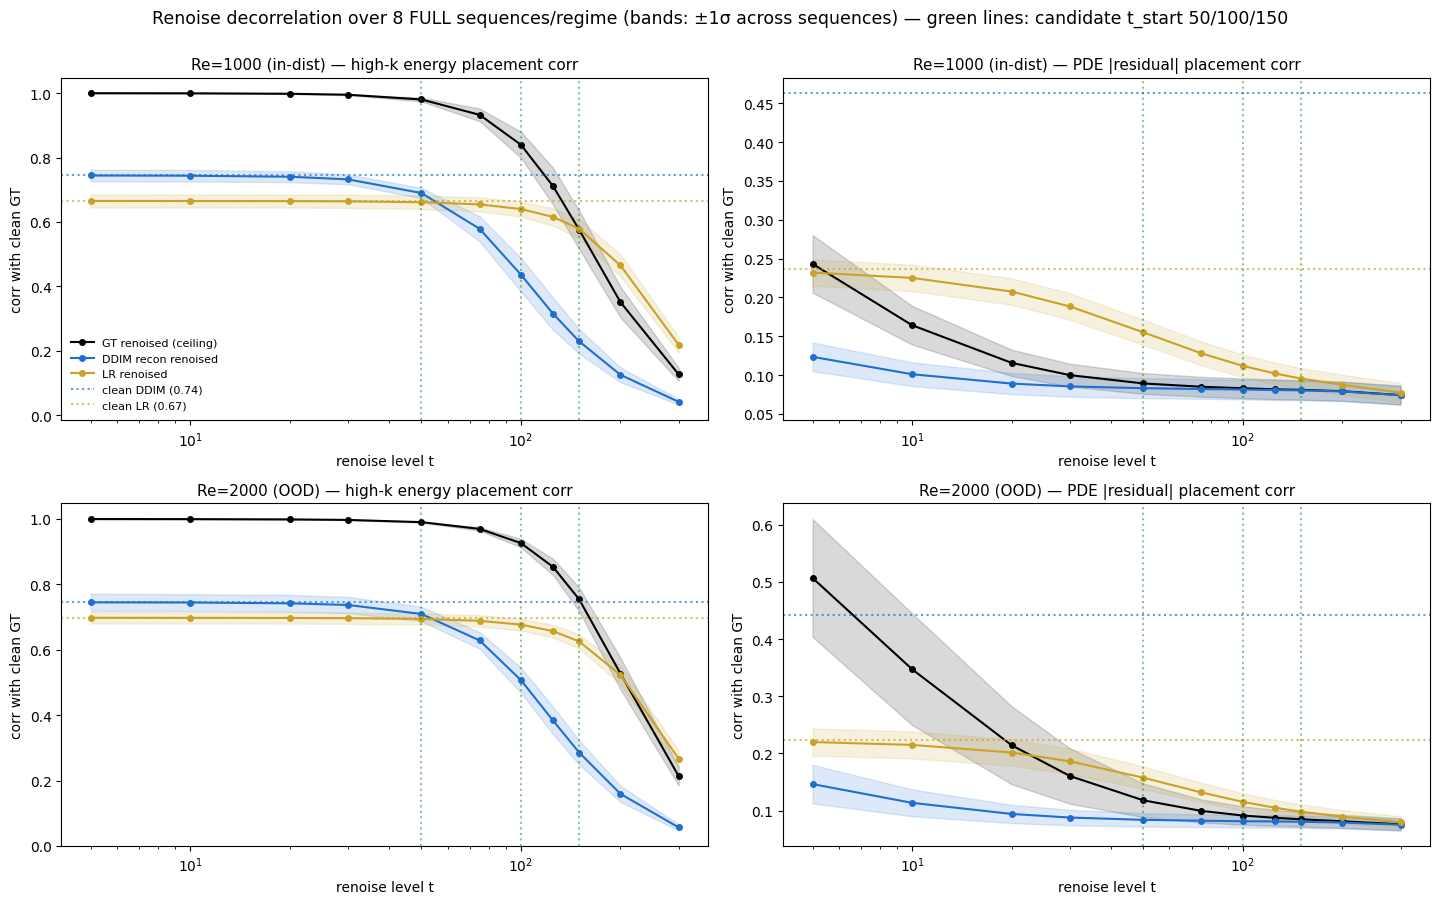

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 9))
FAM = (('gt', 'GT renoised (ceiling)', 'k'), ('ddim', 'DDIM recon renoised', '#1f6fd0'),
       ('lr', 'LR renoised', '#c9a227'))
for ri, re_val in enumerate((1000, 2000)):
    for ci, (mi, name) in enumerate(((0, 'high-k energy placement corr'), (1, 'PDE |residual| placement corr'))):
        ax = axes[ri, ci]
        for fam, lbl, c in FAM:
            m = np.array([ms(re_val, fam, t, mi)[0] for t in TS])
            s = np.array([ms(re_val, fam, t, mi)[1] for t in TS])
            ax.plot(TS, m, '-', marker='o', ms=4, color=c, label=lbl)
            ax.fill_between(TS, m - s, m + s, color=c, alpha=0.15)
        for anchor, c in (('ddim', '#1f6fd0'), ('lr', '#c9a227')):
            av = RES[(re_val, 'clean', anchor)][:, mi].mean()
            ax.axhline(av, color=c, ls=':', alpha=.7, label=f'clean {anchor.upper()} ({av:.2f})')
        for tv in (50, 100, 150):
            ax.axvline(tv, color='green', ls=':', alpha=.45)
        ax.set_xscale('log'); ax.set_xlabel('renoise level t'); ax.set_ylabel('corr with clean GT')
        ax.set_title(f"Re={re_val} ({'in-dist' if re_val == 1000 else 'OOD'}) — {name}", fontsize=11)
        if ri == 0 and ci == 0:
            ax.legend(frameon=False, fontsize=8)
fig.suptitle('Renoise decorrelation over 8 FULL sequences/regime (bands: ±1σ across sequences) — '
             'green lines: candidate t_start 50/100/150', y=1.0, fontsize=12.5)
plt.tight_layout()
plt.savefig('monitoring/ab_pdelocal/renoise_decorrelation.png', dpi=115, bbox_inches='tight')
plt.show()

## Reading

- The **GT-renoised** curve is the hard ceiling: no start field can stay better-correlated than a
  perfect field under the same noise.
- Where the **DDIM** and **LR** curves converge, the start-state choice no longer matters at that
  t_start — the noise has erased their difference.
- Where the DDIM curve still clearly exceeds its own decayed level, reconstruction information
  survives in the start state; the drop-off knee is the largest t_start that preserves it.
- Residual placement that does not survive even small t means residual quality can never be inherited
  from the start state — it must be produced by the chain (or by x0-guidance during it).
- Tight bands across 8 full sequences = the curves are population behavior, not frame luck.